# Architecture Regression — Functional Validation of SNN Variants

Run the 17 known-PASS spike patterns from `reports/` through each SNN architecture variant.
Compare classification accuracy, spike count margin, and weight map fidelity across all designs.

**Validation tiers implemented:**
- **Level 1**: Classification Accuracy (Go/No-Go per pattern)
- **Level 2**: Spike Count Margin (confidence of classification)
- **Level 3**: Weight Map Fidelity (MAE, Max AE, Cosine Similarity vs baseline)

In [125]:
import subprocess
import re
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paths
PROJECT_ROOT = os.path.abspath("..")
PPA_ROOT = os.path.dirname(os.path.abspath("__file__"))  # ppa/

# Load architecture definitions from ground truth
with open(os.path.join(PPA_ROOT, "architectures.json")) as f:
    ARCH_CONFIG = json.load(f)

# Build DESIGNS dict: label -> {params, rtl_file}
# rtl_file determines which make target to use:
#   snn_network.v          -> make ablation-original (special: fixed params)
#   snn_dynamic.v          -> make ablation
#   snn_dynamic_optimized.v -> make ablation-optimized
DESIGNS = {}
for key, arch in ARCH_CONFIG["architectures"].items():
    DESIGNS[arch["label"]] = {
        "params": arch["sim_parameters"],
        "rtl_file": arch["rtl_file"],
    }

# Which design is the golden reference for Level 3 comparisons
BASELINE_LABEL = "Triplet"

print(f"Project root: {PROJECT_ROOT}")
print(f"Designs ({len(DESIGNS)}):")
for label, info in DESIGNS.items():
    param_str = " ".join(f"{k}={v}" for k, v in info["params"].items()) if info["params"] else "(defaults)"
    print(f"  {label}: {param_str}  [rtl: {info['rtl_file']}]")
print(f"Baseline: {BASELINE_LABEL}")

Project root: /Users/dakotabarnes/Develop/274/triplet-snn
Designs (8):
  Original Pair: W_BITS=2 TRACE_BITS=2 TRIPLET_EN=0 LEAK_EN=0  [rtl: snn_network.v]
  Pair: TRIPLET_EN=0  [rtl: snn_dynamic.v]
  Triplet: (defaults)  [rtl: snn_dynamic.v]
  Triplet Optimized: (defaults)  [rtl: snn_dynamic_optimized.v]
  Triplet Opt. Spike-Gated: SPIKE_GATE_EN=1  [rtl: snn_dynamic_optimized.v]
  Triplet Opt. Nearest-Neighbor: MODE=1  [rtl: snn_dynamic_optimized.v]
  Triplet Opt. Seg. Adder: SEG_ADDER_EN=1  [rtl: snn_dynamic_optimized.v]
  Triplet Opt. LUT-STDP: SPIKE_GATE_EN=1 LUT_STDP_EN=1  [rtl: snn_dynamic_optimized.v]
Baseline: Triplet


## Define 17 PASS Patterns

These are the spike patterns where **triplet STDP passes** classification, extracted from:
- `reports/case1_weight_resolution.md` — 6 patterns (weight resolution advantage)
- `reports/case2_low_frequency.md` — 2 patterns (rate-dependent advantage)
- `reports/case3_burst_asymmetry.md` — 9 patterns (burst asymmetry advantage)

In [126]:
PATTERNS = [
    # Case 1: Weight Resolution (6 patterns) — original fails, pair+triplet pass
    {"name": "C1-1",  "case": 1, "white": "0000000000001000000000000010000000001000", "black": "0000100001000010000100001000010000100010", "desc": "3 vs 8 spikes"},
    {"name": "C1-2",  "case": 1, "white": "0000001000000000000100000000000010000000", "black": "0001000100010001000100010001000100010000", "desc": "3 vs 9 spikes"},
    {"name": "C1-3",  "case": 1, "white": "0000000000100000000000000000100000000000", "black": "0000000001110000000000000000000000000000", "desc": "2 vs 3 spikes, minimal"},
    {"name": "C1-4", "case": 1, "white": "0001000000001000000000100000000010000000", "black": "0010010001001001000100100100100100000000", "desc": "4 vs 10 spikes"},
    {"name": "C1-5", "case": 1, "white": "0000000000010000000001000000000100000001", "black": "0010001000100010001000100010001000100000", "desc": "4 vs 9 spikes"},
    {"name": "C1-6", "case": 1, "white": "0000100000000010000000001000000000100000", "black": "0010010010010010010010010010010010010000", "desc": "4 vs 12 spikes"},

    # Case 2: Low-Frequency / Rate-Dependent (2 patterns) — original+pair fail, triplet passes
    {"name": "C2-1",  "case": 2, "white": "0100000000010000000001000000000100000000", "black": "0100100001001000010010000100100001001000", "desc": "4 vs 10 spikes, evenly spaced"},
    {"name": "C2-2", "case": 2, "white": "0010000000001000000000100000000010000000", "black": "0010010000100100001001000010010000100100", "desc": "4 vs 10 spikes, evenly spaced"},

    # Case 3: Burst Asymmetry (9 patterns) — original+pair fail, triplet passes
    # Burst-of-3
    {"name": "C3-1", "case": 3, "white": "0000100000001000000010000000100000001000", "black": "0001110000000011100000000111000000011100", "desc": "burst-of-3, regular spacing"},
    {"name": "C3-2", "case": 3, "white": "0000100000001000000010000000100000000000", "black": "0001110000000111000000011100000001110000", "desc": "burst-of-3, shifted timing (BEST)"},
    {"name": "C3-3", "case": 3, "white": "0000100000010000001000000100000010000000", "black": "0001110000000011100000000111000000011100", "desc": "burst-of-3, alternate WHITE spacing"},
    # Doublet
    {"name": "C3-4", "case": 3, "white": "0000010000000001000000000100000000010000", "black": "0110001100001100011000011000110000110001", "desc": "doublet, regular spacing"},
    {"name": "C3-5", "case": 3, "white": "0000010000000001000000000100000000010000", "black": "1100001100001100011000110000110000110001", "desc": "doublet, shifted BLACK phase"},
    {"name": "C3-6", "case": 3, "white": "0000010000000001000000000100000000010000", "black": "0110001100000110001100001100011000001100", "desc": "doublet, irregular spacing"},
    {"name": "C3-7", "case": 3, "white": "0000001000000000100000000010000000001000", "black": "0110001100001100011000011000110000110001", "desc": "doublet, shifted WHITE phase"},
    {"name": "C3-8", "case": 3, "white": "0000010000000001000000000100000000010000", "black": "1100011000011000011000110001100001100011", "desc": "doublet, alternate spacing"},
    {"name": "C3-9", "case": 3, "white": "0000001000000000100000000010000000001000", "black": "1100001100001100011000110000110000110001", "desc": "doublet, sparse BLACK"},
]

print(f"Total patterns: {len(PATTERNS)}")
for case_num in [1, 2, 3]:
    count = sum(1 for p in PATTERNS if p['case'] == case_num)
    print(f"  Case {case_num}: {count} patterns")

Total patterns: 17
  Case 1: 6 patterns
  Case 2: 2 patterns
  Case 3: 9 patterns


## Simulation Runner

Runs `make ablation` via subprocess for each (architecture, pattern) pair.
Parses testbench stdout for firing counts and weight vectors.

In [127]:
# Regex patterns (weight regex matches viz/plot_weights.py)
RE_FIRING = re.compile(r"Firing counts: Neuron 1 = (\d+), Neuron 2 = (\d+)")
RE_WEIGHTS = re.compile(r"(BEFORE|AFTER) (W[12]): ([\d ]+)")

# Map rtl_file -> make target
MAKE_TARGET = {
    "snn_network.v": "ablation-original",
    "snn_dynamic.v": "ablation",
    "snn_dynamic_optimized.v": "ablation-optimized",
}


def run_simulation(rtl_file, params, white, black):
    """Run make target with given params and spike patterns. Returns stdout.

    The make target is chosen based on rtl_file:
      snn_dynamic.v          -> make ablation          (uses DFLAGS)
      snn_dynamic_optimized.v -> make ablation-optimized (uses DFLAGS_OPT)
      snn_network.v          -> make ablation-original  (fixed preset)
    """
    target = MAKE_TARGET.get(rtl_file, "ablation")
    args = " ".join(f"{k}={v}" for k, v in params.items())
    cmd = f"make {target} {args} SPIKE_WHITE={white} SPIKE_BLACK={black}"
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True, cwd=PROJECT_ROOT)
    if result.returncode != 0:
        print(f"  ERROR: {cmd[:80]}...")
        print(f"  stderr: {result.stderr[:200]}")
    return result.stdout


def parse_results(stdout):
    """Parse testbench output for firing counts and weight vectors."""
    # Extract all firing counts (4 phases: Train '0', Train '1', Test '0', Test '1')
    firings = RE_FIRING.findall(stdout)
    # Extract all weight lines
    weight_matches = RE_WEIGHTS.findall(stdout)

    result = {
        "test0": {"n1": 0, "n2": 0},
        "test1": {"n1": 0, "n2": 0},
        "weights": {"w1": [], "w2": []},
    }

    # Firing counts: last 2 are Test '0' and Test '1'
    if len(firings) >= 4:
        result["test0"] = {"n1": int(firings[-2][0]), "n2": int(firings[-2][1])}
        result["test1"] = {"n1": int(firings[-1][0]), "n2": int(firings[-1][1])}

    # Weight vectors: use AFTER weights from last training phase (before testing)
    # weight_matches is list of (BEFORE|AFTER, W1|W2, "val val val ...")
    after_weights = [(label, wname, vals) for label, wname, vals in weight_matches if label == "AFTER"]
    # After Train '1' is the 2nd pair of AFTER lines (indices 2,3 for W1,W2)
    for label, wname, vals in after_weights:
        key = wname.lower()
        result["weights"][key] = [int(x) for x in vals.strip().split()]
    # Keep only the last w1 and w2 AFTER training (before test phases)
    # The AFTER weights appear after each phase. We want after Train '1' = 2nd AFTER pair.
    after_w1 = [vals for label, wname, vals in after_weights if wname == "W1"]
    after_w2 = [vals for label, wname, vals in after_weights if wname == "W2"]
    if len(after_w1) >= 2:
        result["weights"]["w1"] = [int(x) for x in after_w1[1].strip().split()]
    if len(after_w2) >= 2:
        result["weights"]["w2"] = [int(x) for x in after_w2[1].strip().split()]

    return result


print("Simulation runner ready.")
print(f"Make target mapping: {MAKE_TARGET}")

Simulation runner ready.
Make target mapping: {'snn_network.v': 'ablation-original', 'snn_dynamic.v': 'ablation', 'snn_dynamic_optimized.v': 'ablation-optimized'}


## Run All Simulations

Runs each design against all 17 patterns. This takes ~1-2 minutes total.

In [128]:
results = {}  # results[arch_label][pattern_name] = parsed_dict

total = len(DESIGNS) * len(PATTERNS)
count = 0

for label, info in DESIGNS.items():
    results[label] = {}
    for pattern in PATTERNS:
        count += 1
        stdout = run_simulation(info["rtl_file"], info["params"], pattern["white"], pattern["black"])
        results[label][pattern["name"]] = parse_results(stdout)
    print(f"  [{count}/{total}] Done: {label}")

print(f"\nCompleted {total} simulations.")

  [17/136] Done: Original Pair
  [34/136] Done: Pair
  [51/136] Done: Triplet
  [68/136] Done: Triplet Optimized
  [85/136] Done: Triplet Opt. Spike-Gated
  [102/136] Done: Triplet Opt. Nearest-Neighbor
  [119/136] Done: Triplet Opt. Seg. Adder
  [136/136] Done: Triplet Opt. LUT-STDP

Completed 136 simulations.


## Level 1 — Classification Accuracy

**PASS** = Test '0' and Test '1' have different winners (the neuron with strictly more spikes).
A tie or same winner for both tests = **FAIL**.

In [129]:
def classify(result):
    """Returns (passed, detail_string)."""
    t0, t1 = result["test0"], result["test1"]
    def winner(t):
        if t["n1"] > t["n2"]: return "N1"
        if t["n2"] > t["n1"]: return "N2"
        return "TIE"
    w0, w1 = winner(t0), winner(t1)
    passed = (w0 != w1) and ("TIE" not in [w0, w1])
    return passed, f"T0:{w0} T1:{w1}"


# Build accuracy DataFrame
acc_rows = []
for pattern in PATTERNS:
    row = {"Pattern": pattern["name"], "Case": pattern["case"]}
    for label in DESIGNS:
        passed, detail = classify(results[label][pattern["name"]])
        row[label] = "PASS" if passed else "FAIL"
    acc_rows.append(row)

# Summary row
summary = {"Pattern": "TOTAL", "Case": ""}
for label in DESIGNS:
    pass_count = sum(1 for r in acc_rows if r[label] == "PASS")
    summary[label] = f"{pass_count}/{len(PATTERNS)}"
acc_rows.append(summary)

df_acc = pd.DataFrame(acc_rows)

# Style: green for PASS, red for FAIL
def color_pass_fail(val):
    if val == "PASS":
        return "background-color: #d4edda; color: #155724"
    elif val == "FAIL":
        return "background-color: #f8d7da; color: #721c24"
    return ""

style_cols = list(DESIGNS.keys())
display(df_acc.style.map(color_pass_fail, subset=style_cols))

,Pattern,Case,Original Pair,Pair,Triplet,Triplet Optimized,Triplet Opt. Spike-Gated,Triplet Opt. Nearest-Neighbor,Triplet Opt. Seg. Adder,Triplet Opt. LUT-STDP
0,C1-1,1,FAIL,PASS,PASS,PASS,PASS,PASS,FAIL,PASS
1,C1-2,1,FAIL,PASS,PASS,PASS,PASS,PASS,FAIL,PASS
2,C1-3,1,FAIL,PASS,PASS,PASS,PASS,PASS,FAIL,PASS
3,C1-4,1,FAIL,PASS,PASS,PASS,PASS,PASS,FAIL,PASS
4,C1-5,1,FAIL,PASS,PASS,PASS,PASS,PASS,PASS,PASS
5,C1-6,1,FAIL,PASS,PASS,PASS,PASS,PASS,PASS,PASS
6,C2-1,2,FAIL,FAIL,PASS,PASS,PASS,FAIL,FAIL,PASS
7,C2-2,2,FAIL,FAIL,PASS,PASS,PASS,FAIL,FAIL,PASS
8,C3-1,3,FAIL,FAIL,PASS,PASS,PASS,FAIL,PASS,PASS
9,C3-2,3,FAIL,FAIL,PASS,PASS,PASS,FAIL,PASS,PASS


In [ ]:
from matplotlib.colors import ListedColormap

design_labels = list(DESIGNS.keys())
pattern_names = [p["name"] for p in PATTERNS]

# Build matrix: rows=patterns, cols=architectures (1=PASS, 0=FAIL)
acc_matrix = np.zeros((len(PATTERNS), len(design_labels)))
for i, p in enumerate(PATTERNS):
    for j, label in enumerate(design_labels):
        passed, _ = classify(results[label][p["name"]])
        acc_matrix[i, j] = 1 if passed else 0

fig, ax = plt.subplots(figsize=(10, 8))

cmap = ListedColormap(["#C44E52", "#55A868"])  # 0=FAIL red, 1=PASS green
im = ax.imshow(acc_matrix, aspect="auto", cmap=cmap, vmin=0, vmax=1)

ax.set_xticks(range(len(design_labels)))
ax.set_xticklabels(design_labels, rotation=30, ha="right")
ax.set_yticks(range(len(pattern_names)))
ax.set_yticklabels(pattern_names)
ax.set_title("Classification Accuracy (PASS / FAIL)")

# Annotate cells
for i in range(len(PATTERNS)):
    for j in range(len(design_labels)):
        label_text = "PASS" if acc_matrix[i, j] == 1 else "FAIL"
        ax.text(j, i, label_text, ha="center", va="center", fontsize=7, fontweight="bold", color="white")

# Summary row as x-axis secondary labels
totals = [int(acc_matrix[:, j].sum()) for j in range(len(design_labels))]
for j, t in enumerate(totals):
    ax.text(j, len(PATTERNS) - 0.3, f"{t}/{len(PATTERNS)}", ha="center", va="top",
            fontsize=8, fontweight="bold", color="black")

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#55A868", label="PASS"), Patch(facecolor="#C44E52", label="FAIL")]
ax.legend(handles=legend_elements, loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

## Level 2 — Spike Count Margin

Margin = |winner_spikes - loser_spikes| per test phase. Higher margin = more confident classification.

In [131]:
def compute_margin(result):
    """Returns (margin_test0, margin_test1, total_margin)."""
    m0 = abs(result["test0"]["n1"] - result["test0"]["n2"])
    m1 = abs(result["test1"]["n1"] - result["test1"]["n2"])
    return m0, m1, m0 + m1


# Per-pattern margin table
margin_rows = []
for pattern in PATTERNS:
    row = {"Pattern": pattern["name"], "Case": pattern["case"]}
    for label in DESIGNS:
        m0, m1, total = compute_margin(results[label][pattern["name"]])
        row[label] = total
    margin_rows.append(row)

df_margin = pd.DataFrame(margin_rows)

# Summary: mean margin per architecture
print("Mean total margin per architecture:")
for label in DESIGNS:
    mean_m = df_margin[label].mean()
    print(f"  {label}: {mean_m:.2f}")

print("\nPer-pattern margins:")
display(df_margin)

Mean total margin per architecture:
  Original Pair: 2.35
  Pair: 5.29
  Triplet: 4.76
  Triplet Optimized: 4.76
  Triplet Opt. Spike-Gated: 4.76
  Triplet Opt. Nearest-Neighbor: 5.88
  Triplet Opt. Seg. Adder: 4.59
  Triplet Opt. LUT-STDP: 4.76

Per-pattern margins:


,Pattern,Case,Original Pair,Pair,Triplet,Triplet Optimized,Triplet Opt. Spike-Gated,Triplet Opt. Nearest-Neighbor,Triplet Opt. Seg. Adder,Triplet Opt. LUT-STDP
0,C1-1,1,0,3,3,3,3,3,1,3
1,C1-2,1,1,6,5,5,5,6,2,5
2,C1-3,1,2,2,2,2,2,2,1,2
3,C1-4,1,0,4,5,5,5,4,4,5
4,C1-5,1,6,6,5,5,5,6,3,5
5,C1-6,1,0,8,3,3,3,8,2,3
6,C2-1,2,8,6,6,6,6,8,3,6
7,C2-2,2,8,6,6,6,6,8,3,6
8,C3-1,3,9,8,6,6,6,10,7,6
9,C3-2,3,6,9,8,8,8,8,8,8


## Level 3 — Weight Map Fidelity

Compare post-training weight vectors against the baseline architecture.
Metrics: Mean Absolute Error (MAE), Max Absolute Error, Cosine Similarity.

In [132]:
def compute_weight_fidelity(baseline_weights, test_weights):
    """Compare weight vectors. Returns dict of metrics averaged across w1, w2."""
    metrics = {"mae": [], "max_ae": [], "cos_sim": []}
    for neuron in ["w1", "w2"]:
        b = np.array(baseline_weights[neuron], dtype=float)
        t = np.array(test_weights[neuron], dtype=float)
        if len(b) == 0 or len(t) == 0 or len(b) != len(t):
            continue
        metrics["mae"].append(np.mean(np.abs(b - t)))
        metrics["max_ae"].append(np.max(np.abs(b - t)))
        norm_b, norm_t = np.linalg.norm(b), np.linalg.norm(t)
        if norm_b > 0 and norm_t > 0:
            metrics["cos_sim"].append(np.dot(b, t) / (norm_b * norm_t))
        else:
            metrics["cos_sim"].append(0.0)
    return {k: np.mean(v) if v else float('nan') for k, v in metrics.items()}


# Compute fidelity for each (arch, pattern) vs baseline
fidelity_data = {label: [] for label in DESIGNS}

for pattern in PATTERNS:
    baseline_w = results[BASELINE_LABEL][pattern["name"]]["weights"]
    for label in DESIGNS:
        test_w = results[label][pattern["name"]]["weights"]
        fid = compute_weight_fidelity(baseline_w, test_w)
        fidelity_data[label].append(fid)

# Summary table
fid_rows = []
for label in DESIGNS:
    maes = [f["mae"] for f in fidelity_data[label] if not np.isnan(f["mae"])]
    max_aes = [f["max_ae"] for f in fidelity_data[label] if not np.isnan(f["max_ae"])]
    cos_sims = [f["cos_sim"] for f in fidelity_data[label] if not np.isnan(f["cos_sim"])]
    fid_rows.append({
        "Design": label,
        "Mean MAE": np.mean(maes) if maes else float('nan'),
        "Mean Max AE": np.mean(max_aes) if max_aes else float('nan'),
        "Mean Cosine Sim": np.mean(cos_sims) if cos_sims else float('nan'),
    })

df_fidelity = pd.DataFrame(fid_rows)
print(f"Weight fidelity vs baseline ({BASELINE_LABEL}):")
display(df_fidelity.round(4))

Weight fidelity vs baseline (Triplet):


,Design,Mean MAE,Mean Max AE,Mean Cosine Sim
0,Original Pair,5.3353,11.7647,0.7956
1,Pair,2.3588,5.5882,0.9398
2,Triplet,0.0000,0.0000,1.0000
3,Triplet Optimized,0.0000,0.0000,1.0000
4,Triplet Opt. Spike-Gated,0.0000,0.0000,1.0000
5,Triplet Opt. Nearest-Neighbor,1.7224,4.5000,0.9598
6,Triplet Opt. Seg. Adder,2.6376,6.5000,0.9074
7,Triplet Opt. LUT-STDP,0.0000,0.0000,1.0000


## Summary Table

Combined metrics with delta vs baseline.

In [133]:
# Build combined summary
summary_rows = []
baseline_pass_count = sum(1 for p in PATTERNS if classify(results[BASELINE_LABEL][p["name"]])[0])
baseline_mean_margin = df_margin[BASELINE_LABEL].mean()

for label in DESIGNS:
    pass_count = sum(1 for p in PATTERNS if classify(results[label][p["name"]])[0])
    mean_margin = df_margin[label].mean()
    fid = df_fidelity[df_fidelity["Design"] == label].iloc[0]

    # Delta vs baseline
    acc_delta = pass_count - baseline_pass_count
    margin_delta = mean_margin - baseline_mean_margin

    summary_rows.append({
        "Design": label,
        "Accuracy": f"{pass_count}/{len(PATTERNS)}",
        "Mean Margin": round(mean_margin, 2),
        # "Weight MAE": round(fid["Mean MAE"], 4),
        "Cosine Sim": round(fid["Mean Cosine Sim"], 4),
        "\u0394 Accuracy": f"{acc_delta:+d}" if label != BASELINE_LABEL else "baseline",
        "\u0394 Margin": f"{margin_delta:+.2f}" if label != BASELINE_LABEL else "baseline",
    })

df_summary = pd.DataFrame(summary_rows)
print("Combined Regression Summary:")
display(df_summary)

Combined Regression Summary:


,Design,Accuracy,Mean Margin,Cosine Sim,Δ Accuracy,Δ Margin
0,Original Pair,0/17,2.35,0.7956,-17,-2.41
1,Pair,6/17,5.29,0.9398,-11,+0.53
2,Triplet,17/17,4.76,1.0000,baseline,baseline
3,Triplet Optimized,17/17,4.76,1.0000,+0,+0.00
4,Triplet Opt. Spike-Gated,17/17,4.76,1.0000,+0,+0.00
5,Triplet Opt. Nearest-Neighbor,11/17,5.88,0.9598,-6,+1.12
6,Triplet Opt. Seg. Adder,11/17,4.59,0.9074,-6,-0.18
7,Triplet Opt. LUT-STDP,17/17,4.76,1.0000,+0,+0.00


## Classification Accuracy Bar Chart

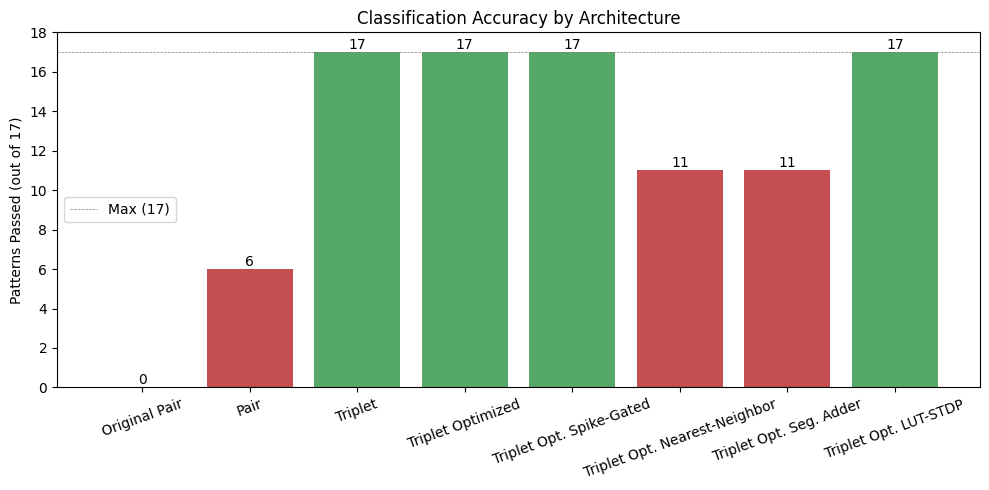

In [134]:
fig, ax = plt.subplots(figsize=(10, 5))

labels = list(DESIGNS.keys())
pass_counts = [sum(1 for p in PATTERNS if classify(results[l][p["name"]])[0]) for l in labels]

colors = ["#55A868" if c == len(PATTERNS) else "#C4A000" if c >= len(PATTERNS) * 0.7 else "#C44E52" for c in pass_counts]
bars = ax.bar(labels, pass_counts, color=colors)
ax.set_ylabel(f"Patterns Passed (out of {len(PATTERNS)})")
ax.set_title("Classification Accuracy by Architecture")
ax.set_ylim(0, len(PATTERNS) + 1)
ax.axhline(len(PATTERNS), color="gray", linestyle="--", linewidth=0.5, label=f"Max ({len(PATTERNS)})")
ax.bar_label(bars, fmt="%d", fontsize=10)
ax.tick_params(axis="x", rotation=20)
ax.legend()

plt.tight_layout()
plt.show()

## Margin Heatmap

Patterns on Y-axis, architectures on X-axis, colored by total spike count margin.

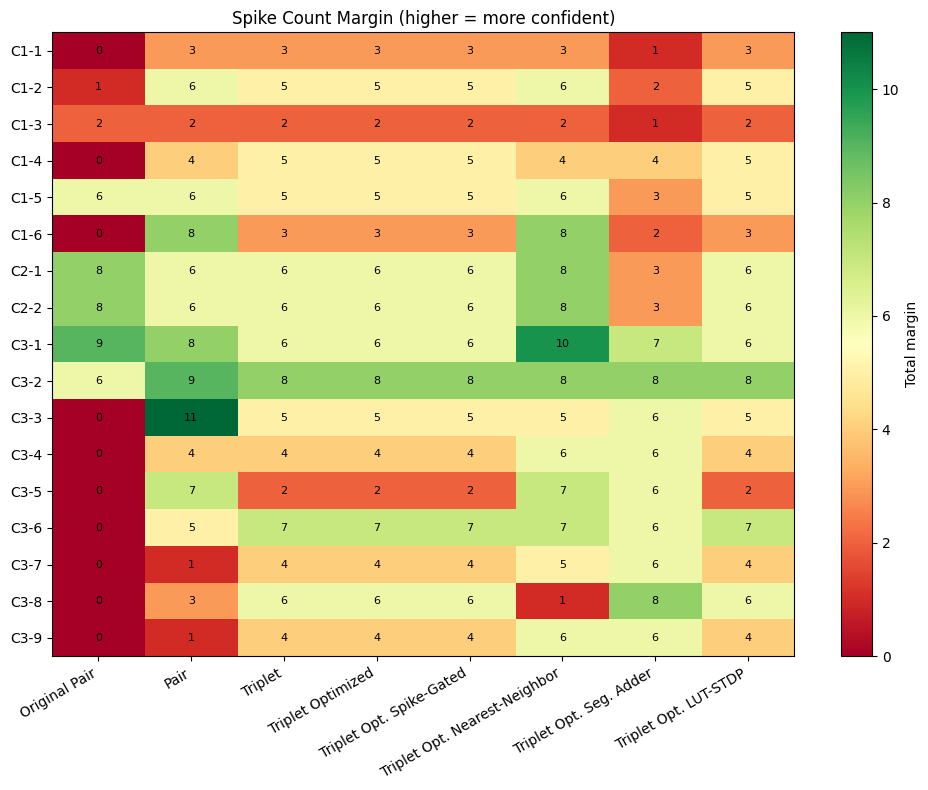

In [135]:
fig, ax = plt.subplots(figsize=(10, 8))

labels = list(DESIGNS.keys())
pattern_names = [p["name"] for p in PATTERNS]

# Build matrix: rows=patterns, cols=architectures
margin_matrix = np.zeros((len(PATTERNS), len(labels)))
for i, p in enumerate(PATTERNS):
    for j, label in enumerate(labels):
        _, _, total = compute_margin(results[label][p["name"]])
        margin_matrix[i, j] = total

im = ax.imshow(margin_matrix, aspect="auto", cmap="RdYlGn")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_yticks(range(len(pattern_names)))
ax.set_yticklabels(pattern_names)
ax.set_title("Spike Count Margin (higher = more confident)")

# Annotate cells
for i in range(len(PATTERNS)):
    for j in range(len(labels)):
        ax.text(j, i, f"{int(margin_matrix[i, j])}", ha="center", va="center", fontsize=8)

plt.colorbar(im, ax=ax, label="Total margin")
plt.tight_layout()
plt.show()

## Export CSV

In [136]:
# # Detailed per-pattern results
# export_rows = []
# for pattern in PATTERNS:
#     for label in DESIGNS:
#         r = results[label][pattern["name"]]
#         passed, detail = classify(r)
#         m0, m1, total = compute_margin(r)
#         export_rows.append({
#             "Pattern": pattern["name"],
#             "Case": pattern["case"],
#             "Architecture": label,
#             "Test0_N1": r["test0"]["n1"],
#             "Test0_N2": r["test0"]["n2"],
#             "Test1_N1": r["test1"]["n1"],
#             "Test1_N2": r["test1"]["n2"],
#             "Pass": passed,
#             "Margin_Test0": m0,
#             "Margin_Test1": m1,
#             "Margin_Total": total,
#         })

# df_export = pd.DataFrame(export_rows)
# csv_path = os.path.join(os.path.dirname(os.path.abspath("__file__")), "regression_results.csv")
# df_export.to_csv(csv_path, index=False)
# print(f"Saved: {csv_path}")
# print(f"Total rows: {len(df_export)} ({len(PATTERNS)} patterns x {len(DESIGNS)} architectures)")